# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- Rolling IQR anomaly detection
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: commitizen
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\commitizen.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\ocel2_commitizen.sqlite
Closed event type id: 105


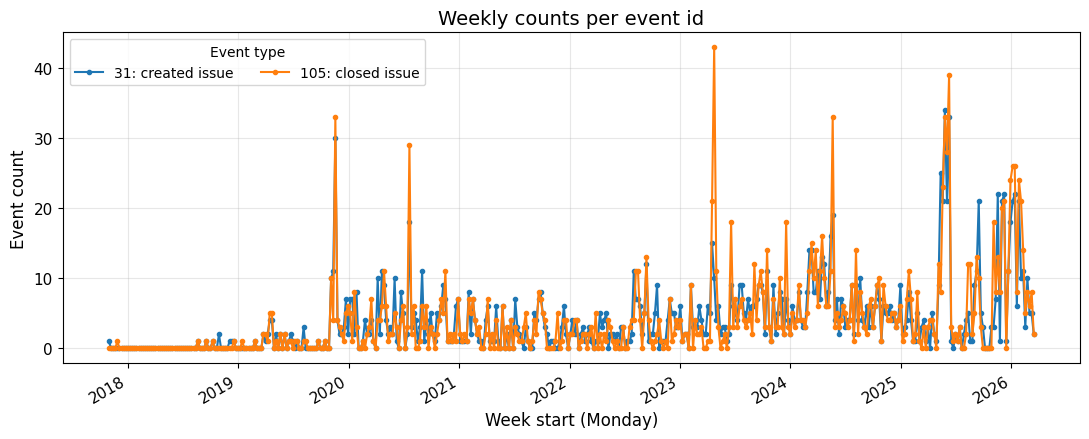

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\weekly_open_closed_summary.csv


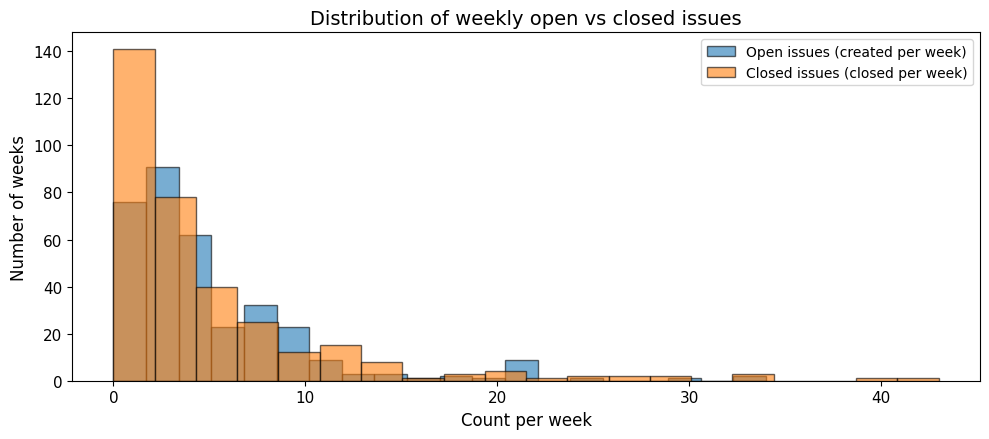

,Open issues (weekly created),Closed issues (weekly closed)
count,339.00,339.00
mean,5.04,5.10
std,5.19,6.37
min,0.00,0.00
25%,2.00,1.00
50%,4.00,3.00
75%,7.00,6.00
max,34.00,43.00


In [1]:
from pathlib import Path

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("commitizen")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_no_titles_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR for detecting the anomalies 


In [2]:
from functions.anomaly import rolling_iqr_detect
from functions.config import IQR_CONFIG

rolling_iqr_anomalies = rolling_iqr_detect(
    weekly[cfg.closed_event_type_id],
    **IQR_CONFIG,
)
rolling_iqr_anomalies.to_csv(cfg.tables_dir / "rolling_iqr_anomalies.csv", index=False)
print(
    f"Detected {int(rolling_iqr_anomalies['is_anomaly'].sum())} "
    f"rolling-IQR anomalies for event_type_id={cfg.closed_event_type_id}."
)
rolling_iqr_anomalies.head()


Detected 25 rolling-IQR anomalies for event_type_id=105.


,week_start,value,rolling_q1,rolling_q3,iqr,lower_bound,upper_bound,is_anomaly,anomaly_direction,anomaly_score
0,2017-10-30,0,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
1,2017-11-27,1,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
2,2018-08-20,1,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
3,2018-09-17,1,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
4,2018-10-08,1,NaN,NaN,NaN,NaN,NaN,False,normal,0.0


## 3. Export anomaly object / event IDs


In [3]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(
    rolling_iqr_anomalies, eventsPerobj_df, cfg
)
anomaly_object_ids.head()



,week_start,object_id
0,2023-04-24,98774
1,2020-07-20,105200
2,2020-04-27,107795
3,2020-04-27,108224
4,2025-06-09,23136


## 4. Anomaly plots


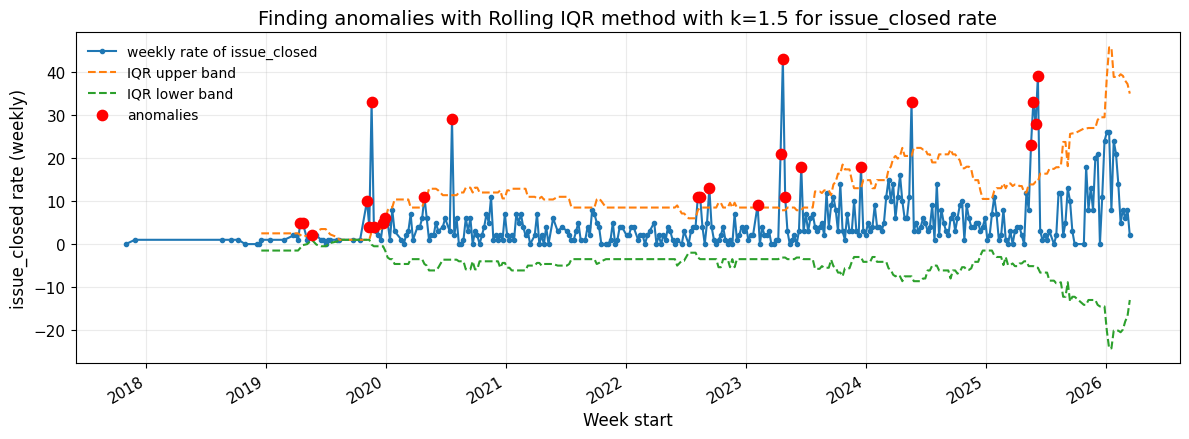

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


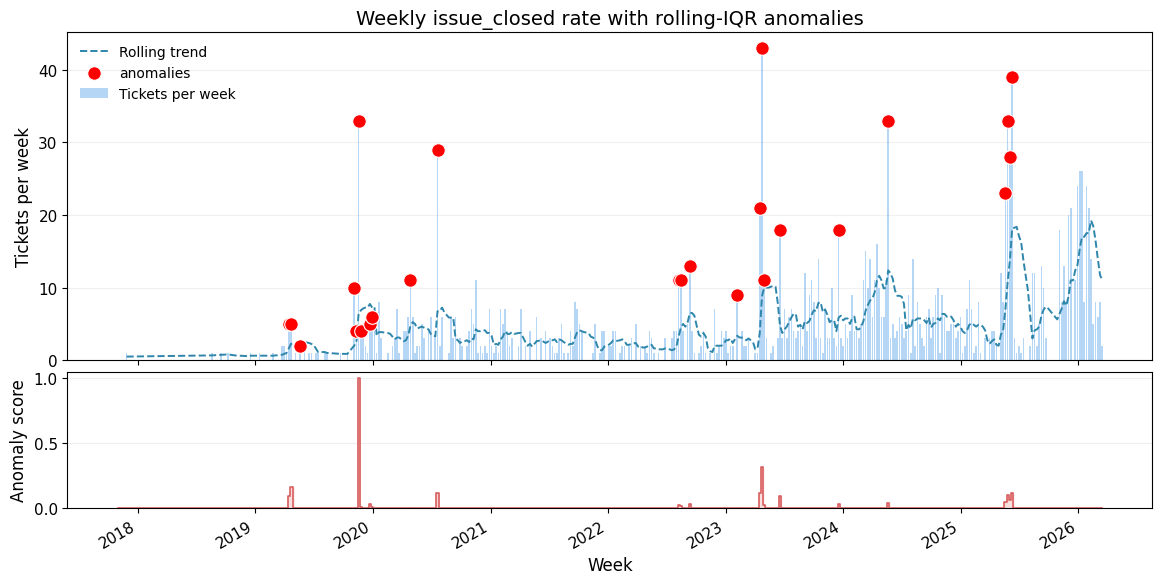

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/commitizen')

In [4]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(rolling_iqr_anomalies, cfg)


## 5. Commit context and type classification

Link commits to issues that closed in anomaly weeks via the same `event_id` join as 8b. Classify those messages for the weekly stacked plot, and save overlapping `anomaly_issue_commit_categories`.


commit_context summary: 25 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\commit_context.csv

=== Anomaly issue commit categories (overlapping, event_id link) ===
Anomaly issues: 421
Issues with classified commits: 266
Issues with no classified commit (assigned to other): 155
Issues in more than one category: 64
  feature_work  46
  bug_fixes     63
  tech_debt     165
  docs          70
  other         189
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\anomaly_issue_commit_categories.csv
commit_typeclass_per_week summary: 25 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.131
  bug_fixes     0.147
  tech_debt     0.523
  docs          0.128
  other         0.071

Mean category ratios by anomaly_direction:
  [hig

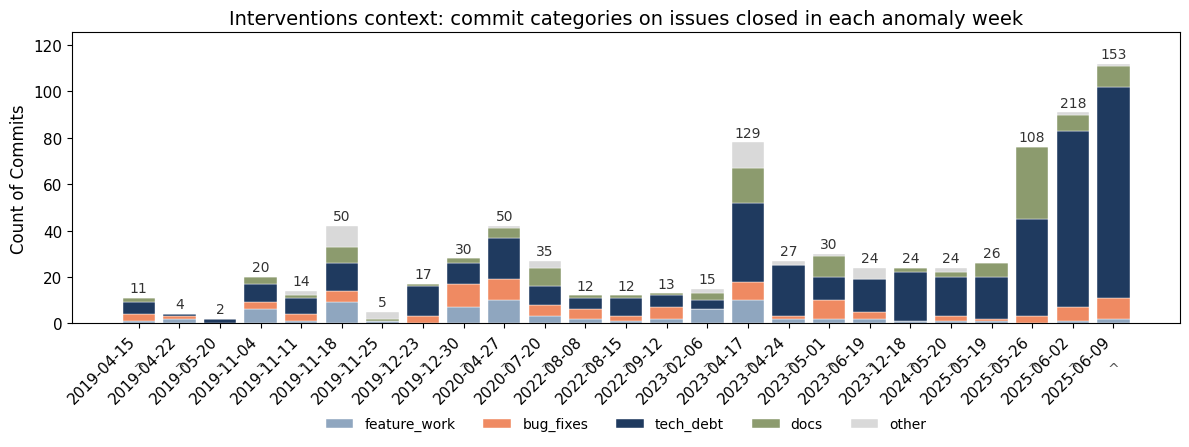

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/commitizen')

In [5]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join, anomaly_issue_commit_categories = build_commit_context(
    rolling_iqr_anomalies, eventsPerobj_df, objects_attributes, cfg, anomaly_object_ids
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log: viewpoint of issues


In [6]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 25893 events, 1709 cases
  case:concept:name           concept:name            time:timestamp
0            100019                created 2020-11-21 14:00:43+00:00
1            100019              commented 2020-11-21 14:03:19+00:00
2            100019               reviewed 2020-11-21 14:07:30+00:00
3            100019  head_ref_force_pushed 2020-11-21 15:17:01+00:00
4            100019              committed 2020-11-21 15:31:42+00:00
5            100019  head_ref_force_pushed 2020-11-21 15:31:50+00:00
6            100019                 merged 2020-11-21 15:40:18+00:00
7            100019                 closed 2020-11-21 15:40:18+00:00
8            100062                created 2020-11-21 13:59:15+00:00
9            100062              commented 2020-11-21 14:01:39+00:00


## 8a. Category-log preprocess 

Clean the raw step-6 `flat` log for commit-category discovery: keep cases that end in `closed` or `head_ref_deleted`, then drop traces with any activity repeating more than 7 times. Independent of step 8 (`MAX_REP=5`).


In [7]:
from functions.preprocessing import preprocess_flat_log

CATEGORY_MAX_REP = 10
flat_df_category_clean = preprocess_flat_log(flat, cfg, max_rep=CATEGORY_MAX_REP) 


=== Category-log preprocess (end=closed/head_ref_deleted, max_rep=10) ===
Raw: 1709 cases | 25893 events
After incomplete-end filter: 1302 cases | 17821 events
After max_rep=10: 1235 cases | 15101 events


In [10]:
from functions.discovery import select_miners

# Available: alpha_classic, inductive_IM, heuristics_dep_0.5/0.6/0.7,
# inductive_IMf_noise_0.2/0.3/0.4, split_miner_eps_*_eta_*
# None runs all miners.
DISCOVERY_MINERS = [
    "inductive_IMf_noise_0.2",
    "split_miner_eps_0.2_eta_0.5",
    "heuristics_dep_0.5",
]


## 8b. Commit-category event logs (8a cleaned flat) and discovery in each action category

Classify every commit message and put each case from `flat_df_category_clean` into every category log that matches at least one of its commits (logs overlap, one issue can have two commits, we consider the issue for both commits category). Then run discovery F1 on those five logs plus that cleaned whole log. Discovery methods come from `DISCOVERY_MINERS` in the cell after 8a (`None` runs all).


In [11]:
from functions.commits import build_whole_commit_category_logs
from functions.discovery import evaluate_clean_logs, select_miners

category_logs, issue_commit_categories, commit_classified_all = build_whole_commit_category_logs(
    flat_df_category_clean, eventsPerobj_df, objects_attributes, cfg
)

commit_category_log_groups_df = {**category_logs, "whole": flat_df_category_clean}

consolidated_results_table_commit_categories, commit_category_log_groups_eventlog, _ = evaluate_clean_logs(
    commit_category_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_commit_categories.csv"
)
consolidated_results_table_commit_categories.head()


=== Commit message classification (preprocessed whole log) ===
Preprocessed whole-log cases: 1235
Classified unique commits: 3233
  feature_work  319
  bug_fixes     436
  tech_debt     1862
  docs          431
  other         185
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\commit_classified_all.csv

=== Issue commit categories (overlapping, preprocessed whole log) ===
Whole-log cases: 1235
Issues with classified commits: 945
Issues with no classified commit (assigned to other): 290
Issues in issue_commit_categories: 1235
Issues in more than one category log: 130
  feature_work  83
  bug_fixes     149
  tech_debt     651
  docs          174
  other         364
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\issue_commit_categories.csv

=== Preprocessed-log commit-category subsets (

c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 806/806 [00:06<00:00, 127.02it/s]

Expected records: 18 | Observed: 18

7) Consolidated results table in clean logs
        log_name             discovery_method  n_cases  avg_cycle_time_days  \
0      bug_fixes           heuristics_dep_0.5      149            41.602269   
1           docs           heuristics_dep_0.5      174            21.892618   
2   feature_work           heuristics_dep_0.5       83           138.490093   
3          other           heuristics_dep_0.5      364            93.397712   
4      tech_debt           heuristics_dep_0.5      651            19.050482   
5          whole           heuristics_dep_0.5     1235            43.724701   
6      bug_fixes      inductive_IMf_noise_0.2      149            41.602269   
7           docs      inductive_IMf_noise_0.2      174            21.892618   
8   feature_work      inductive_IMf_noise_0.2       83           138.490093   
9          other      inductive_IMf_noise_0.2      364            93.397712   
10     tech_debt      inductive_IMf_noise_0.2     

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,bug_fixes,heuristics_dep_0.5,149,41.602269,15.865772,0.504903,0.884842,0.313477,0.462945,658.0,38.0,0.429565,ok,None
1,docs,heuristics_dep_0.5,174,21.892618,13.747126,0.485073,0.883363,0.363652,0.515209,620.0,43.0,0.443609,ok,None
2,feature_work,heuristics_dep_0.5,83,138.490093,19.433735,0.481109,0.871015,0.413867,0.561117,610.0,39.0,0.438330,ok,None
3,other,heuristics_dep_0.5,364,93.397712,10.291209,0.493579,0.858488,0.395900,0.541898,673.0,40.0,0.455185,ok,None
4,tech_debt,heuristics_dep_0.5,651,19.050482,13.122888,0.520265,0.869227,0.440466,0.584663,800.0,50.0,0.435159,ok,None


## 8c. Anomaly vs normal logs from cleaned flat, then discovery F1

Split `flat_df_category_clean` by anomaly object IDs from step 3: keep matching cases as the anomaly log and the rest as the normal log. Then run discovery F1 on anomaly, normal, and the cleaned whole log using `DISCOVERY_MINERS`.


In [12]:
from functions.ocel_flatten import split_flat_by_anomaly_object_ids
from functions.discovery import evaluate_clean_logs, select_miners

anomaly_log_df, normal_log_df = split_flat_by_anomaly_object_ids(
    flat_df_category_clean, anomaly_object_ids
)

anomaly_normal_log_groups_df = {
    "anomaly": anomaly_log_df,
    "normal": normal_log_df,
    "whole": flat_df_category_clean,
}

consolidated_results_table_anomaly_normal, _, _ = evaluate_clean_logs(
    anomaly_normal_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_anomaly_normal.csv",
)
consolidated_results_table_anomaly_normal


Anomaly log: 286 cases | 3455 events
Normal log: 949 cases | 11646 events


replaying log with TBR, completed traces :: 100%|██████████| 806/806 [00:06<00:00, 121.23it/s]

Expected records: 9 | Observed: 9

7) Consolidated results table in clean logs
  log_name             discovery_method  n_cases  avg_cycle_time_days  \
0  anomaly           heuristics_dep_0.5      286            69.141023   
1   normal           heuristics_dep_0.5      949            36.064988   
2    whole           heuristics_dep_0.5     1235            43.724701   
3  anomaly      inductive_IMf_noise_0.2      286            69.141023   
4   normal      inductive_IMf_noise_0.2      949            36.064988   
5    whole      inductive_IMf_noise_0.2     1235            43.724701   
6  anomaly  split_miner_eps_0.2_eta_0.5      286            69.141023   
7   normal  split_miner_eps_0.2_eta_0.5      949            36.064988   
8    whole  split_miner_eps_0.2_eta_0.5     1235            43.724701   

   avg_trace_length  generalization   fitness  precision   f_score    size  \
0         12.080420        0.530556  0.847590   0.457020  0.593841   757.0   
1         12.271865        0.50116

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,anomaly,heuristics_dep_0.5,286,69.141023,12.080420,0.530556,0.847590,0.457020,0.593841,757.0,53.0,0.439510,ok,None
1,normal,heuristics_dep_0.5,949,36.064988,12.271865,0.501168,0.875949,0.337464,0.487222,1092.0,74.0,0.425000,ok,None
2,whole,heuristics_dep_0.5,1235,43.724701,12.227530,0.544230,0.872337,0.388304,0.537396,1126.0,73.0,0.421106,ok,None
3,anomaly,inductive_IMf_noise_0.2,286,69.141023,12.080420,0.866752,0.968980,0.242638,0.388095,319.0,11.0,0.628959,ok,None
4,normal,inductive_IMf_noise_0.2,949,36.064988,12.271865,0.858609,0.962258,0.347794,0.510923,369.0,9.0,0.654618,ok,None
5,whole,inductive_IMf_noise_0.2,1235,43.724701,12.227530,0.875530,0.953141,0.291954,0.446991,420.0,11.0,0.638889,ok,None
6,anomaly,split_miner_eps_0.2_eta_0.5,286,69.141023,12.080420,0.766024,0.828793,0.489824,0.615740,346.0,64.0,0.394322,ok,None
7,normal,split_miner_eps_0.2_eta_0.5,949,36.064988,12.271865,0.699911,0.895356,0.291515,0.439829,487.0,22.0,0.488608,ok,None
8,whole,split_miner_eps_0.2_eta_0.5,1235,43.724701,12.227530,0.737308,0.726853,0.325949,0.450069,675.0,118.0,0.394822,ok,None


## 8d. Anomaly x commit-category logs, then discovery F1

Cross `anomaly_log_df` / `normal_log_df` from 8c with overlapping `category_logs` from 8b: each case stays in every matching category, then those logs are split into anomaly vs normal. Then run discovery F1 on the ten combined groups plus the cleaned whole log using `DISCOVERY_MINERS`.


In [16]:
from functions.discovery import evaluate_clean_logs, select_miners

anomaly_ids = set(anomaly_log_df["case:concept:name"].astype(str))
normal_ids = set(normal_log_df["case:concept:name"].astype(str))

anomaly_category_log_groups_df = {
    **{f"anomaly_{name}": df[df["case:concept:name"].astype(str).isin(anomaly_ids)].copy()
       for name, df in category_logs.items()},
    **{f"normal_{name}": df[df["case:concept:name"].astype(str).isin(normal_ids)].copy()
       for name, df in category_logs.items()},
    "whole": flat_df_category_clean,
}

consolidated_results_table_anomaly_categories, _, _ = evaluate_clean_logs(
    anomaly_category_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_anomaly_categories.csv",
)
consolidated_results_table_anomaly_categories


replaying log with TBR, completed traces :: 100%|██████████| 806/806 [00:06<00:00, 116.54it/s]

Expected records: 33 | Observed: 33

7) Consolidated results table in clean logs
                log_name             discovery_method  n_cases  \
0      anomaly_bug_fixes           heuristics_dep_0.5       32   
1           anomaly_docs           heuristics_dep_0.5       42   
2   anomaly_feature_work           heuristics_dep_0.5       24   
3          anomaly_other           heuristics_dep_0.5      113   
4      anomaly_tech_debt           heuristics_dep_0.5      118   
5       normal_bug_fixes           heuristics_dep_0.5      117   
6            normal_docs           heuristics_dep_0.5      132   
7    normal_feature_work           heuristics_dep_0.5       59   
8           normal_other           heuristics_dep_0.5      251   
9       normal_tech_debt           heuristics_dep_0.5      533   
10                 whole           heuristics_dep_0.5     1235   
11     anomaly_bug_fixes      inductive_IMf_noise_0.2       32   
12          anomaly_docs      inductive_IMf_noise_0.2       4

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,anomaly_bug_fixes,heuristics_dep_0.5,32,37.511103,12.500000,0.408935,0.862126,0.475358,0.612820,312.0,17.0,0.492063,ok,None
1,anomaly_docs,heuristics_dep_0.5,42,23.599774,12.976190,0.476007,0.877565,0.377063,0.527483,299.0,19.0,0.493776,ok,None
2,anomaly_feature_work,heuristics_dep_0.5,24,86.217460,12.750000,0.414839,0.915194,0.374795,0.531804,252.0,10.0,0.502488,ok,None
3,anomaly_other,heuristics_dep_0.5,113,131.144580,9.893805,0.527332,0.894513,0.451187,0.599826,380.0,23.0,0.476038,ok,None
4,anomaly_tech_debt,heuristics_dep_0.5,118,19.450729,14.330508,0.497694,0.803695,0.759890,0.781178,678.0,53.0,0.435374,ok,None
5,normal_bug_fixes,heuristics_dep_0.5,117,42.721220,16.786325,0.480422,0.887292,0.300626,0.449093,624.0,35.0,0.432781,ok,None
6,normal_docs,heuristics_dep_0.5,132,21.349432,13.992424,0.479328,0.889359,0.346857,0.499072,518.0,30.0,0.437500,ok,None
7,normal_feature_work,heuristics_dep_0.5,59,159.753537,22.152542,0.459163,0.883506,0.381879,0.533264,601.0,36.0,0.444660,ok,None
8,normal_other,heuristics_dep_0.5,251,76.404102,10.470120,0.474666,0.892512,0.433938,0.583957,654.0,39.0,0.452252,ok,None
9,normal_tech_debt,heuristics_dep_0.5,533,18.961872,12.855535,0.480538,0.845221,0.368452,0.513192,730.0,41.0,0.440382,ok,None


## 15. Petri nets by commit category: events related to each commit category


the question:
    what process is discovered for each overlapping commit category in the preprocessed whole log?
the input:
    category_logs from step 8b (overlapping category subsets of flat_df_category_clean)
the output:
    petri net per category log (inductive_IMf_noise_0.3)


In [14]:
#graphviz path 
import os
from pathlib import Path
import shutil

GRAPHVIZ_BIN = Path(r"C:\Program Files\Graphviz\bin")  # change if yours is elsewhere

if not (GRAPHVIZ_BIN / "dot.exe").exists():
    raise FileNotFoundError(
        f"dot.exe not found in {GRAPHVIZ_BIN}. "
        "Install Graphviz and set GRAPHVIZ_BIN to its bin folder."
    )

os.environ["PATH"] = str(GRAPHVIZ_BIN) + os.pathsep + os.environ.get("PATH", "")
print("dot found at:", shutil.which("dot"))

dot found at: C:\Program Files\Graphviz\bin\dot.EXE


feature_work


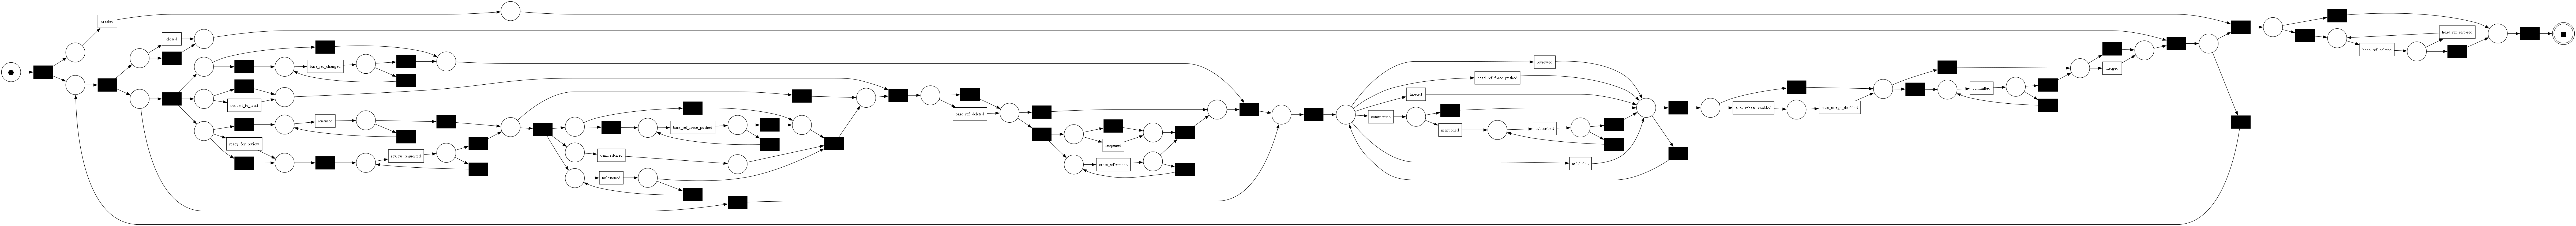

bug_fixes


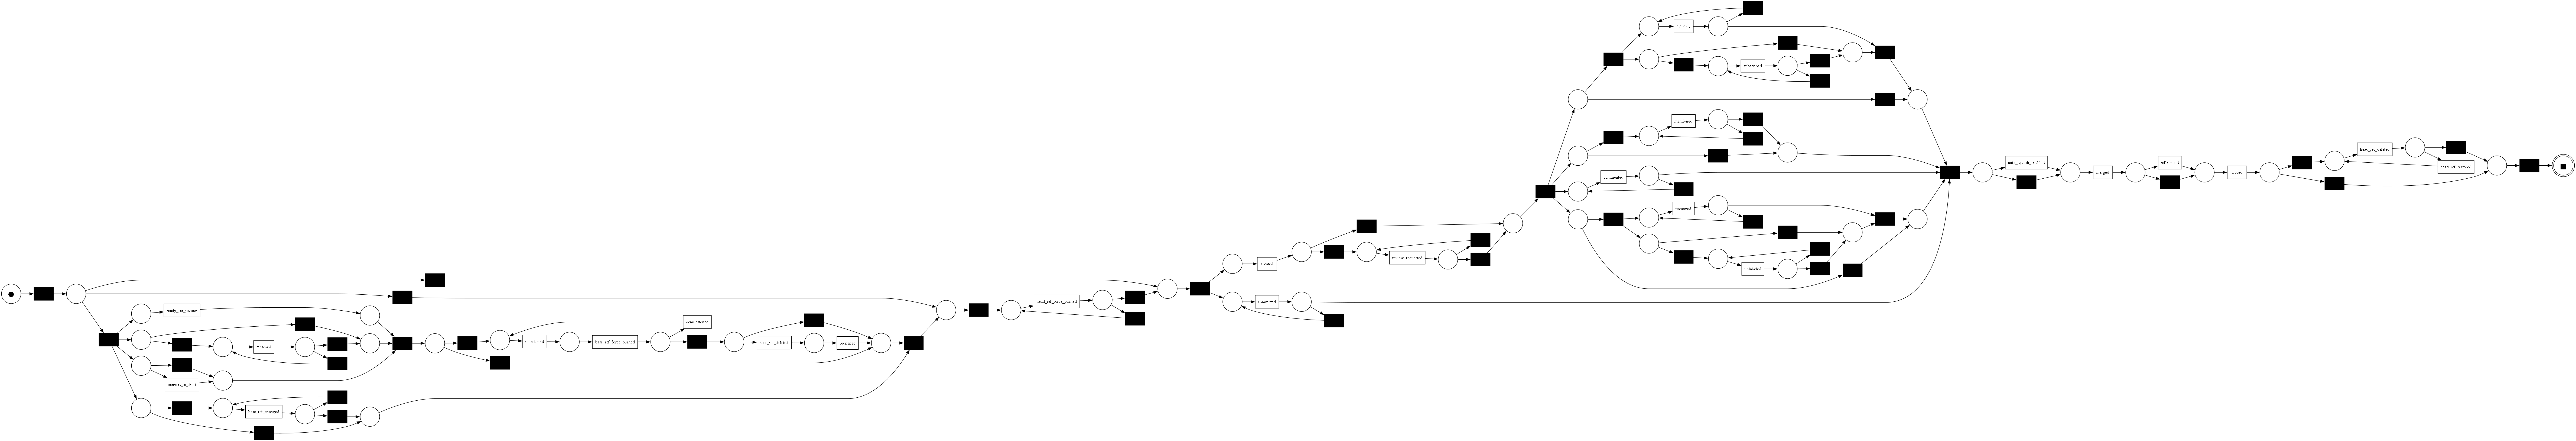

tech_debt


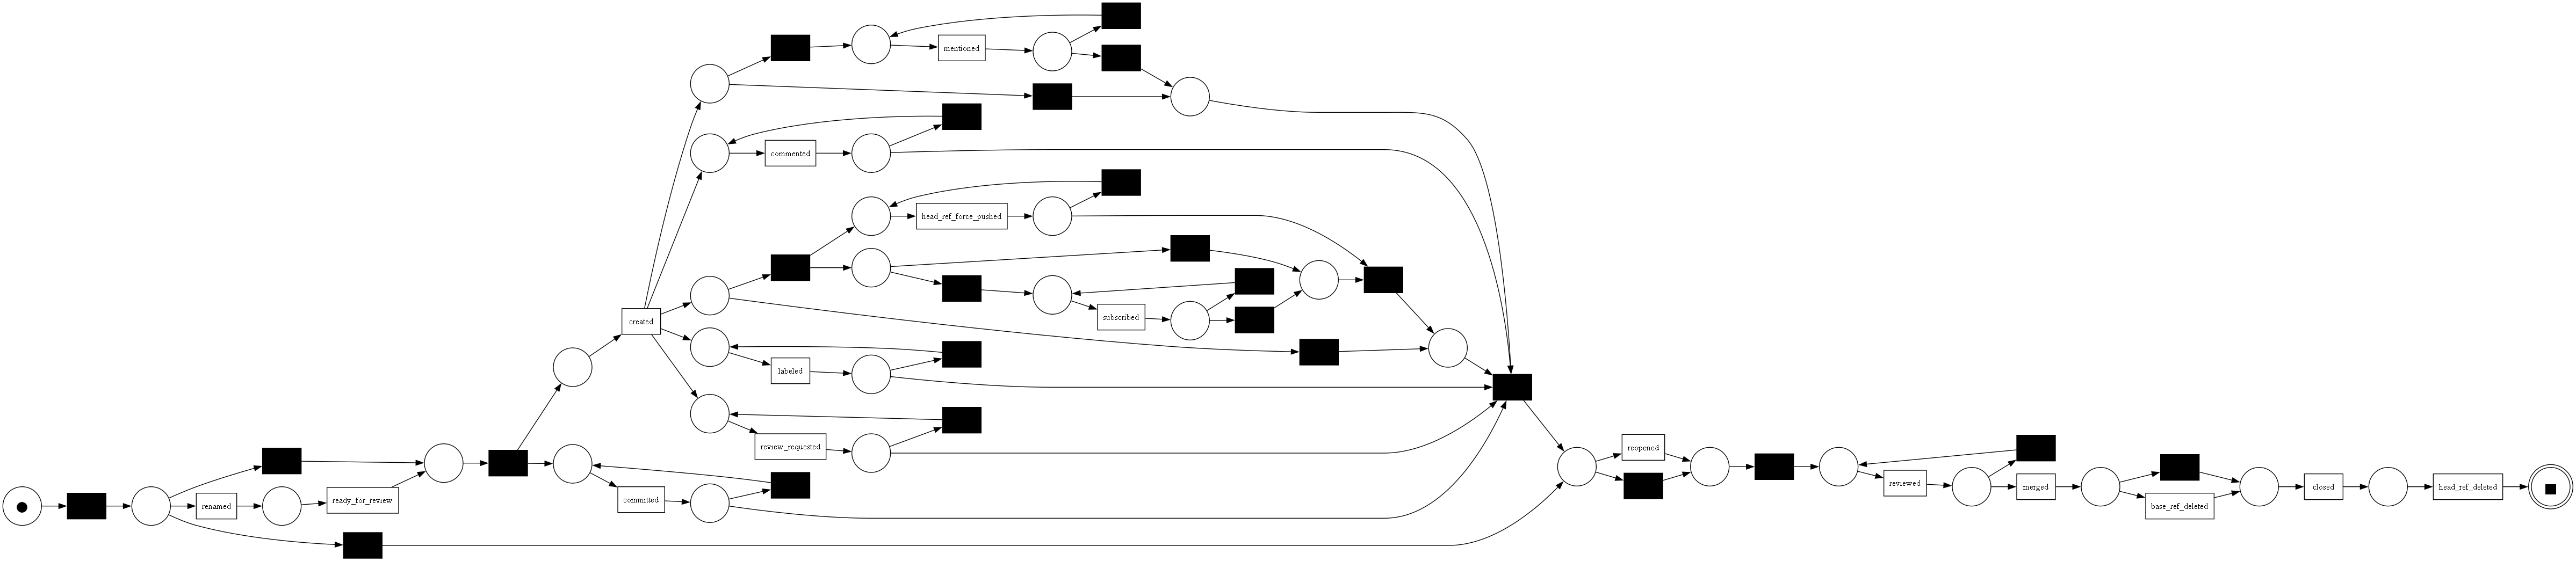

docs


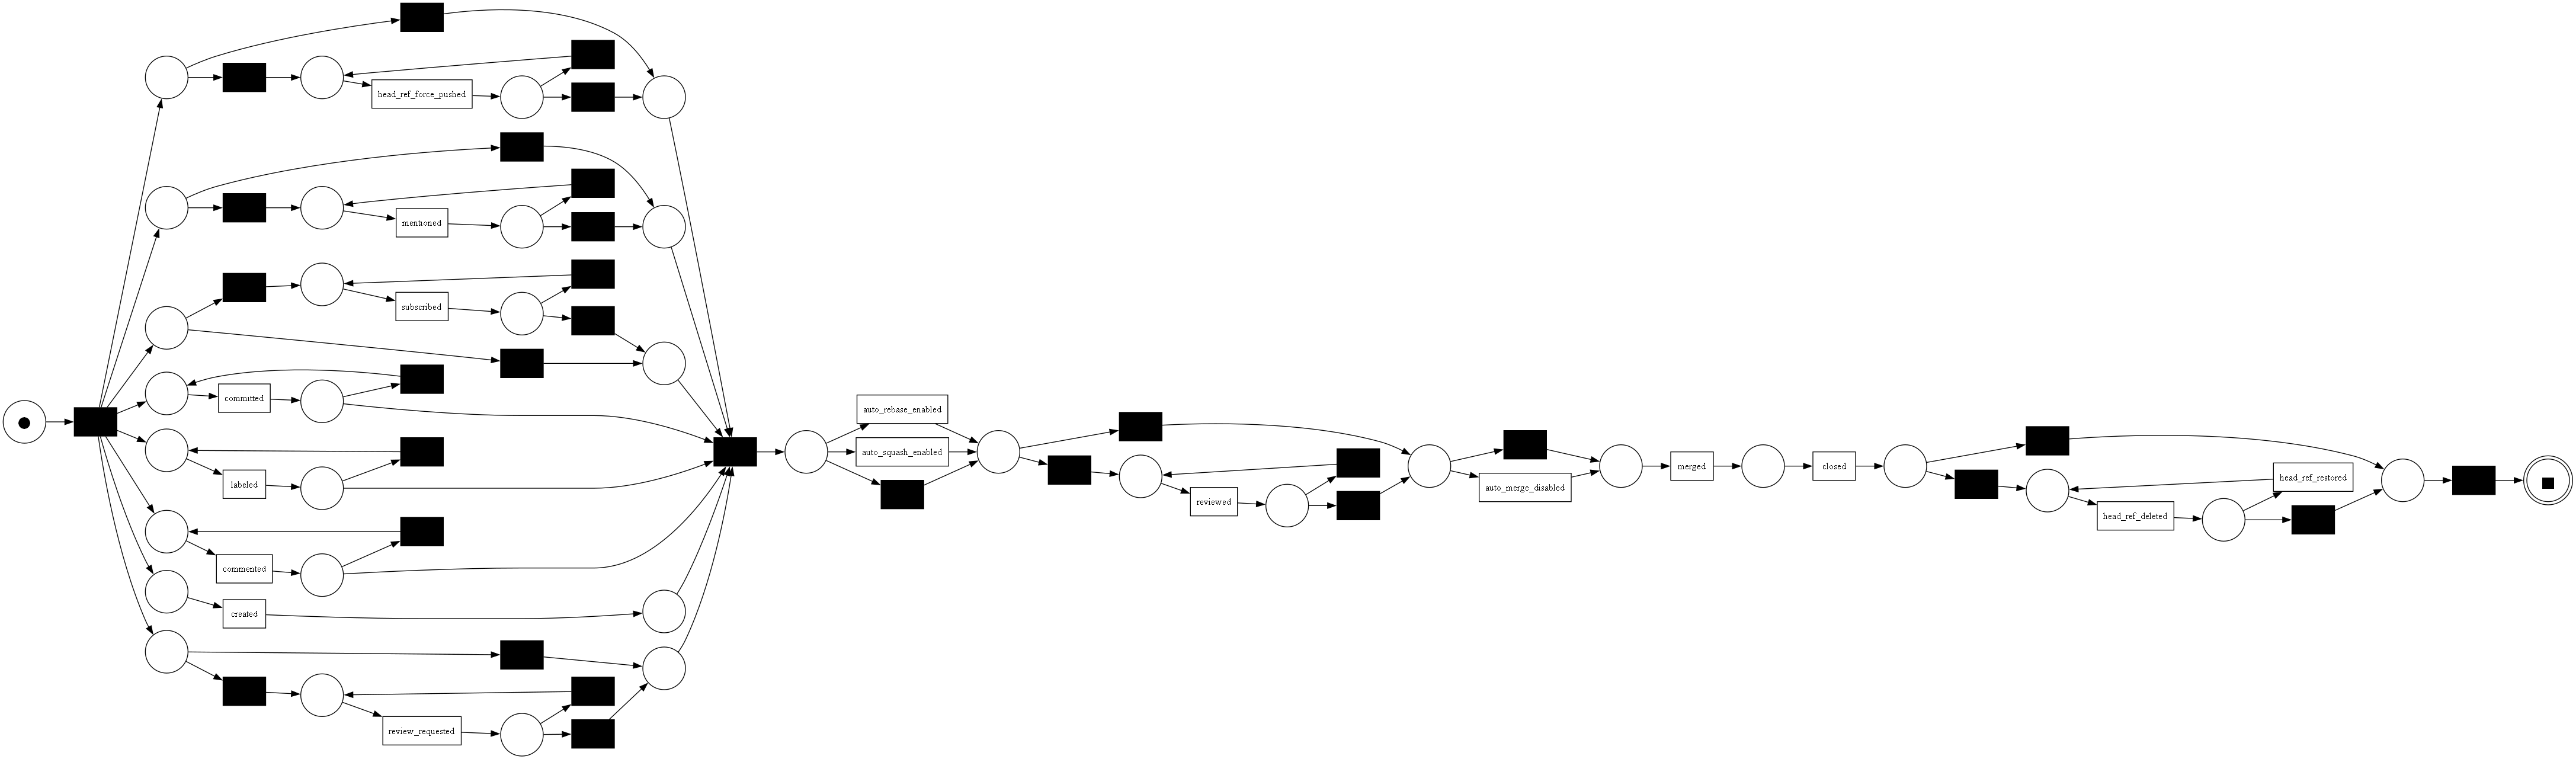

other


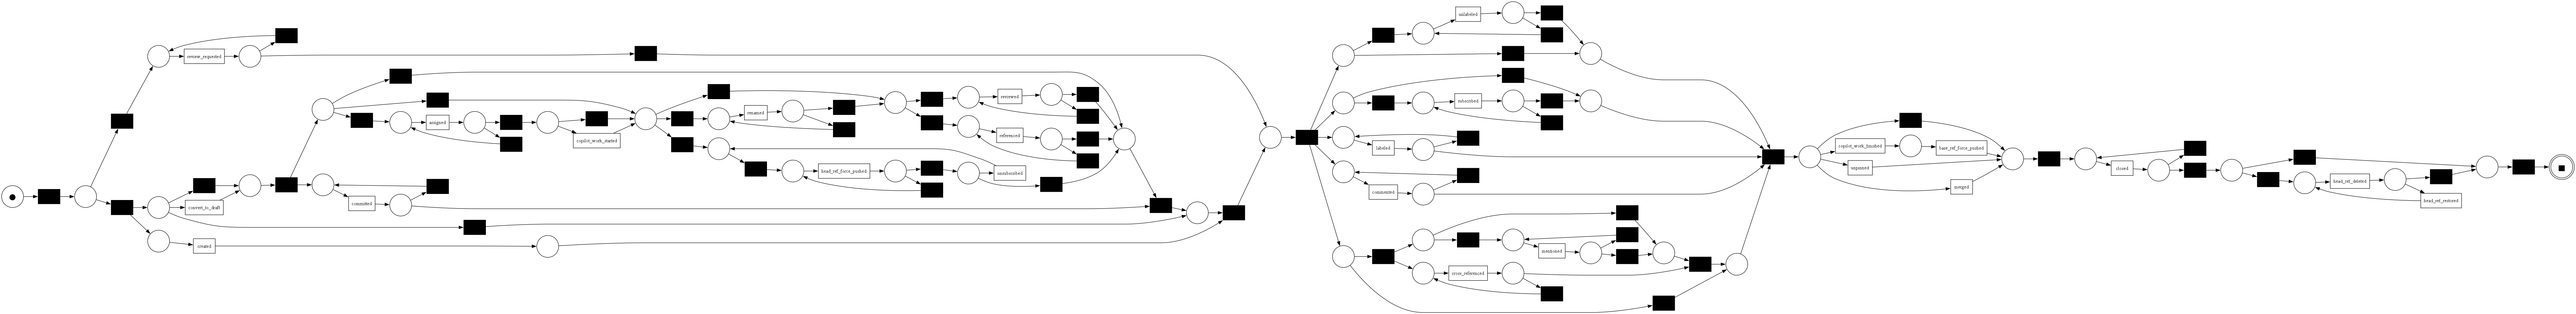

In [15]:
import pm4py
from functions.discovery import df_to_event_log, select_miners

miners = select_miners(["inductive_IMf_noise_0.3"])

for name, df in category_logs.items():
    print(name)
    elog = df_to_event_log(df)
    net, im, fm = miners["inductive_IMf_noise_0.3"](elog)
    pm4py.view_petri_net(net, im, fm)
